# Árboles de Decisión: Regresión y Ajuste de Hiperparámetros

## Introducción
En este ejercicio generaremos un árbol de decisión que, a través de Regresión, nos permita predecir si una persona sufrirá diabetes o no.

### DataSet: Pacientes Enfermos con Diabetes
Se obtuvieron diez variables basales (edad, sexo, índice de masa corporal, presión arterial promedio y seis mediciones del suero sanguíneo) para cada uno de los $n = 442$ pacientes con diabetes, así como la respuesta de interés: una medida cuantitativa de la progresión de la enfermedad un año después del inicio.

* **age:** Edad en años
* **sex:** Sexo
* **bmi:** Índice de masa corporal (*body mass index*)
* **bp:** Presión arterial promedio (*average blood pressure*)
* **s1:** Células T (*T-Cells*, tipo de glóbulos blancos)
* **s2:** Lipoproteínas de baja densidad (*low-density lipoproteins*)
* **s3:** Lipoproteínas de alta densidad (*high-density lipoproteins*)
* **s4:** Hormona estimulante de la tiroides (*thyroid stimulating hormone*)[cite: 1]
* **s5:** Lamotrigina[cite: 1]
* **s6:** Nivel de azúcar en sangre (*blood sugar level*)

**Objetivo:** Medida cuantitativa de la progresión de la enfermedad.

In [ ]:
# 1. Cargamos y preparamos el dataset
import pandas as pd
from sklearn.datasets import load_diabetes

datos = load_diabetes()
X = pd.DataFrame(datos.data, columns=datos.feature_names)
Y = datos.target

In [ ]:
# 2. Se analiza cantidad de valores nulos que pudiera haber
X.isna().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [ ]:
# 3. Se ven las columnas que tiene el dataframe
X.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

## Modelamiento (Primeros pasos)
Usando la librería SKLEARN, generaremos un árbol de decisión para regresión.

**Pregunta:** Indica qué significan cada una de las variables siguientes y qué indican las medidas de verificación usadas.

In [ ]:
# 4. Construcción del modelo inicial
from sklearn.tree import DecisionTreeRegressor

mo2 = DecisionTreeRegressor()
mo2.fit(X, Y)
Yhat = mo2.predict(X)

**Solución a las variables:**
* **DecisionTreeRegressor:** Es un parámetro/clase que indica al algoritmo que construya un árbol de decisión de regresión. Analiza las características y entrena el modelo para predecir un resultado en forma de un valor numérico continuo (no discreto).
* **MO2:** Nombre asignado al modelo de árbol de decisión, el cual se ajusta (`fit`) con los datos del DataFrame ($X$) y la variable a predecir ($Y$).

In [ ]:
# 5. Se medirá la calidad del modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(Y, Yhat)
mae = mean_absolute_error(Y, Yhat)
R2 = r2_score(Y, Yhat)

print("MSE: ", mse)
print("MAE: ", mae)
print("R^2: ", R2)

MSE:  0.0
MAE:  0.0
R^2:  1.0


### Observaciones del Modelo 1:
* **MSE:** El Error Cuadrático Medio es el promedio del cuadrado de las diferencias entre el valor observado y el valor predicho[cite: 1]. Mientras menor sea su valor, mejor. En este caso, un MSE de $0.0$ parece un buen indicador.
* **MAE:** El Error Absoluto Medio es el promedio de las diferencias en valor absoluto entre el valor observado y el predicho[cite: 1]. Lo ideal es que tienda a cero. En este caso, un MAE de $0.0$ parece un buen indicador[cite: 1].
* **$R^2$:** Indica que no existe diferencia alguna entre el valor actual y el predicho. Aparenta ser un modelo predictivo perfecto (lo cual es técnicamente imposible en la práctica). De hecho, lo sospechoso es que MSE y MAE sean cero.

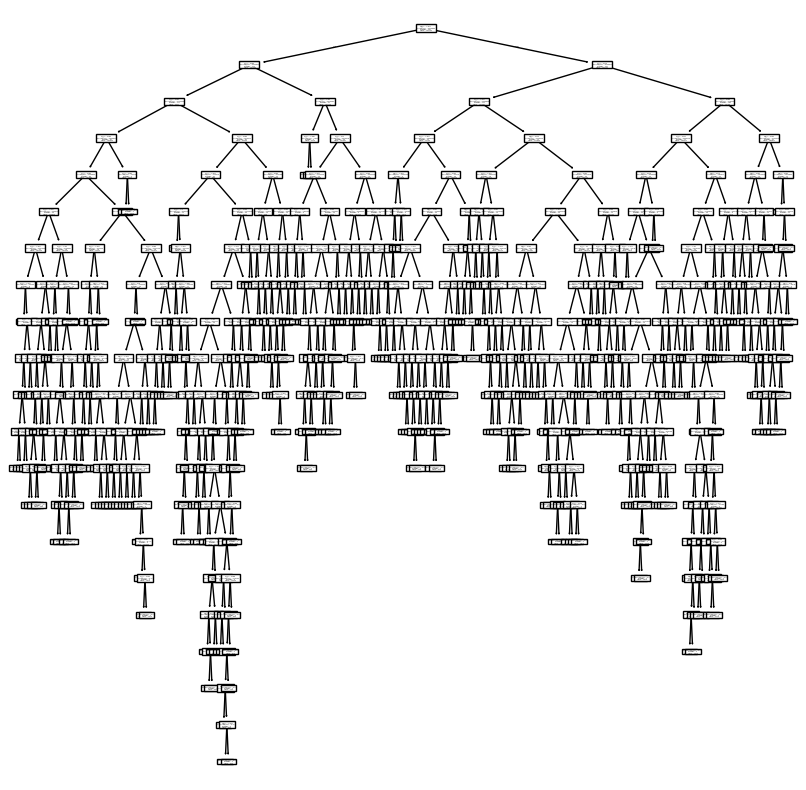

In [ ]:
# 7. Visualizamos el árbol generado
import matplotlib.pyplot as plt
from sklearn import tree

plt.subplots(1, 1, figsize=(10, 10))
_= tree.plot_tree(mo2)

## Evitando el Overfitting

**Pregunta:** ¿Por qué existe OVERFITTING?

**Solución:**
El modelo se generó tomando en cuenta todos los datos del DataFrame. Una de las debilidades de este algoritmo es que tiende a memorizar el patrón de los datos. Que el MAE sea cero al evaluar con los mismos datos de entrenamiento es un claro indicativo de **OVERFITTING** (sobreajuste).

Esto indica que debemos particionar los datos en un conjunto de entrenamiento (*Train*) y otro de prueba (*Test*).

In [ ]:
# 9. Se define el Test y el Train
from sklearn.model_selection import train_test_split

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2)

In [ ]:
# 10. Se entrena el modelo (fit) y se obtienen sus métricas de desempeño reales
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mo2 = DecisionTreeRegressor()
mo2.fit(Xtrain, Ytrain)
Yhat = mo2.predict(Xtest)

mse = mean_squared_error(Ytest, Yhat)
mae = mean_absolute_error(Ytest, Yhat)
R2 = r2_score(Ytest, Yhat)

print("MSE: ", mse)
print("MAE: ", mae)
print("R^2: ", R2)

MSE:  8118.7191011235955
MAE:  68.85393258426966
R^2:  -0.39285601658837943


**Solución:**
Como puede verse, en este caso el MSE, MAE y $R^2$ difieren completamente de los valores iniciales. Ello confirma que, en el primer modelo, el algoritmo cayó en OVERFITTING.

In [ ]:
# 12. Calculamos el R2 "a mano":
1 - sum((Ytest - Yhat)**2) / sum((Ytest - Ytest.mean())**2)

np.float64(-0.3928560165883792)

**Solución:**
En este caso nuestro $R^2$ no tiende a 1 (se mueve en rangos bajos). El modelo no logra explicar de forma óptima la variación de los valores alrededor del promedio, lo que indica que el árbol por defecto rinde de forma pobre fuera de sus datos de entrenamiento.

In [ ]:
# 13. Importancia de características
mo2.feature_importances_

array([0.06609532, 0.0204846 , 0.21459081, 0.10430481, 0.05986453,
       0.02363451, 0.05023679, 0.01445488, 0.39603062, 0.05030314])

In [ ]:
# 14. Mapeo claro de predictores y su importancia
colnames = X.columns.values.tolist()
predictors = colnames[:10]
list(zip(predictors, mo2.feature_importances_))

[('age', np.float64(0.0660953197992063)),
 ('sex', np.float64(0.02048459541141795)),
 ('bmi', np.float64(0.21459080982778492)),
 ('bp', np.float64(0.10430480775320687)),
 ('s1', np.float64(0.05986453120582303)),
 ('s2', np.float64(0.023634505802445215)),
 ('s3', np.float64(0.0502367912023445)),
 ('s4', np.float64(0.014454878065577865)),
 ('s5', np.float64(0.39603061991805333)),
 ('s6', np.float64(0.05030314101413997))]

In [ ]:
# 15. Verificación de las columnas de entrenamiento
Xtrain.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

> **Nota:** De los resultados anteriores se observa que la variable más importante suele ser `s5` (lamotrigina), seguida por `bmi` (índice de masa corporal). Ambas resultan determinantes en el cálculo del árbol de regresión.

## Sintonización (Tuning) del Modelo

**Preguntas:**
1. ¿Cómo se realiza esta sintonización?
2. ¿Qué hiperparámetros se están modificando?
3. ¿Qué ocurre si ingresas otros valores? (Prueba)

**Solución:**
La sintonización (*tuning*) de un modelo consiste en encontrar los mejores valores de hiperparámetros que permitan generalizar o predecir con el menor error posible.

Utilizaremos `GridSearchCV` para evaluar combinaciones. Se modifican hiperparámetros como `max_depth` (profundidad máxima) y `min_samples_split` (mínimo de muestras para dividir un nodo)

In [ ]:
# 18. Se redefinen o aseguran los conjuntos de entrenamiento y test
from sklearn.model_selection import train_test_split

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2)

> **Parámetros a probar:**
> * `max_depth`: Variará entre 3, 4 y 5.
> * `min_samples_split`: Variará entre 2, 3 y 4.
> * `cv`: Se fija en 10 validaciones cruzadas (*folds*).

In [ ]:
# 20. Búsqueda por malla (GridSearchCV)
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

model = DecisionTreeRegressor()
params = {
    "max_depth": np.arange(3, 6),         # [3, 4, 5]
    "min_samples_split": np.arange(2, 5)  # [2, 3, 4]
}

grid = GridSearchCV(estimator=model, param_grid=params, cv=10)
grid.fit(Xtrain, Ytrain)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': array([3, 4, 5]),
                         'min_samples_split': array([2, 3, 4])})

In [ ]:
# 22. Evaluación de los mejores hiperparámetros encontrados
print("Mejor score:", grid.best_score_)
print("Mejores parámetros:", grid.best_params_)

Mejor score: 0.3333127032220463
Mejores parámetros: {'max_depth': np.int64(3), 'min_samples_split': np.int64(3)}


In [ ]:
# 23. Tabla completa de resultados del tuning
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003140,0.000427,0.002095,0.000516,3,2,"{'max_depth': 3, 'min_samples_split': 2}",0.365461,0.361638,0.222004,0.498433,0.039661,0.381940,0.045172,0.615366,0.224197,0.450142,0.320402,0.177919,6
1,0.003094,0.000393,0.001981,0.000298,3,3,"{'max_depth': 3, 'min_samples_split': 3}",0.365461,0.361638,0.222004,0.498433,0.039661,0.511052,0.045172,0.615366,0.224197,0.450142,0.333313,0.186399,1
2,0.002759,0.000158,0.001708,0.000074,3,4,"{'max_depth': 3, 'min_samples_split': 4}",0.365461,0.361638,0.222004,0.498433,0.039661,0.511052,0.045172,0.615366,0.224197,0.450142,0.333313,0.186399,1
3,0.003285,0.000268,0.002020,0.000390,4,2,"{'max_depth': 4, 'min_samples_split': 2}",0.332105,0.396423,0.191517,0.442586,0.203395,0.384874,0.139302,0.631894,0.266995,0.289444,0.327853,0.137253,4
4,0.003850,0.000451,0.002254,0.000273,4,3,"{'max_depth': 4, 'min_samples_split': 3}",0.332105,0.396423,0.191517,0.442586,0.203395,0.455904,0.139302,0.631894,0.265879,0.239163,0.329817,0.144229,3
5,0.003097,0.000254,0.001771,0.000238,4,4,"{'max_depth': 4, 'min_samples_split': 4}",0.332105,0.396423,0.191517,0.445377,0.203395,0.384874,0.139302,0.631894,0.281265,0.259564,0.326571,0.138083,5
6,0.003388,0.000184,0.001833,0.000206,5,2,"{'max_depth': 5, 'min_samples_split': 2}",0.164382,0.301059,0.114560,0.373254,-0.012018,0.376476,0.175622,0.584252,-0.004433,0.138525,0.221168,0.177265,8
7,0.003645,0.000207,0.001989,0.000323,5,3,"{'max_depth': 5, 'min_samples_split': 3}",0.164382,0.173824,0.114560,0.373254,0.018629,0.379331,0.175622,0.584252,-0.004433,0.145320,0.212474,0.171987,9
8,0.004306,0.000585,0.002236,0.000430,5,4,"{'max_depth': 5, 'min_samples_split': 4}",0.304028,0.293791,0.114560,0.375239,0.018629,0.450360,0.175622,0.584252,0.010953,0.082199,0.240963,0.182834,7


In [ ]:
# 24. Fila con los datos del mejor modelo resultante
pd.DataFrame(grid.cv_results_).iloc[grid.best_index_]

,1
mean_fit_time,0.003094
std_fit_time,0.000393
mean_score_time,0.001981
std_score_time,0.000298
param_max_depth,3
param_min_samples_split,3
params,"{'max_depth': 3, 'min_samples_split': 3}"
split0_test_score,0.365461
split1_test_score,0.361638
split2_test_score,0.222004


## Elección con Métricas de Pérdida / Scoring Específicas

Para profundizar en el uso del parámetro `scoring`, puedes consultar:
* [Scikit-Learn: Pre-defined scoring parameters](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)
* [Scikit-Learn: Defining your scoring strategy](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring)

In [ ]:
# 26. Optimización explícita utilizando scoring = 'r2'
grid = GridSearchCV(estimator=model, param_grid=params, cv=10, scoring='r2')
grid.fit(Xtrain, Ytrain)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': array([3, 4, 5]),
                         'min_samples_split': array([2, 3, 4])},
             scoring='r2')

In [ ]:
# 27. Calidad del modelo óptimo obtenido
print("Mejor Score (R2):", grid.best_score_)
print("Mejores Parámetros:", grid.best_params_)

Mejor Score (R2): 0.3333127032220463
Mejores Parámetros: {'max_depth': np.int64(3), 'min_samples_split': np.int64(2)}


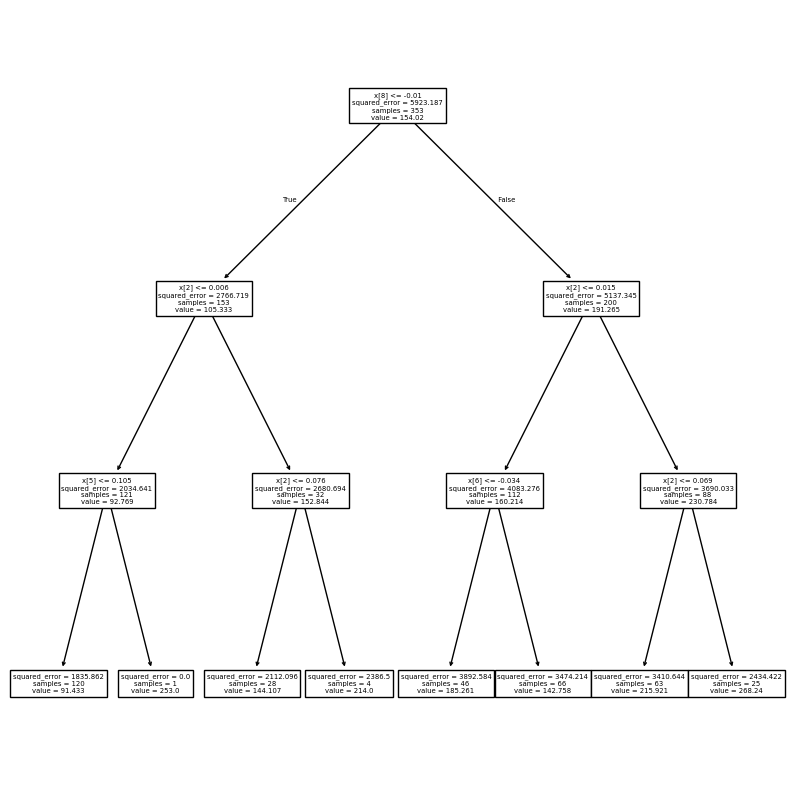

In [ ]:
# 28. Visualización del árbol ganador
import matplotlib.pyplot as plt
from sklearn import tree

plt.subplots(1, 1, figsize=(10, 10))
_= tree.plot_tree(grid.best_estimator_)

MSE: 4742.885354063803
MAE: 52.51302196365214
R2: 0.19425861055125393


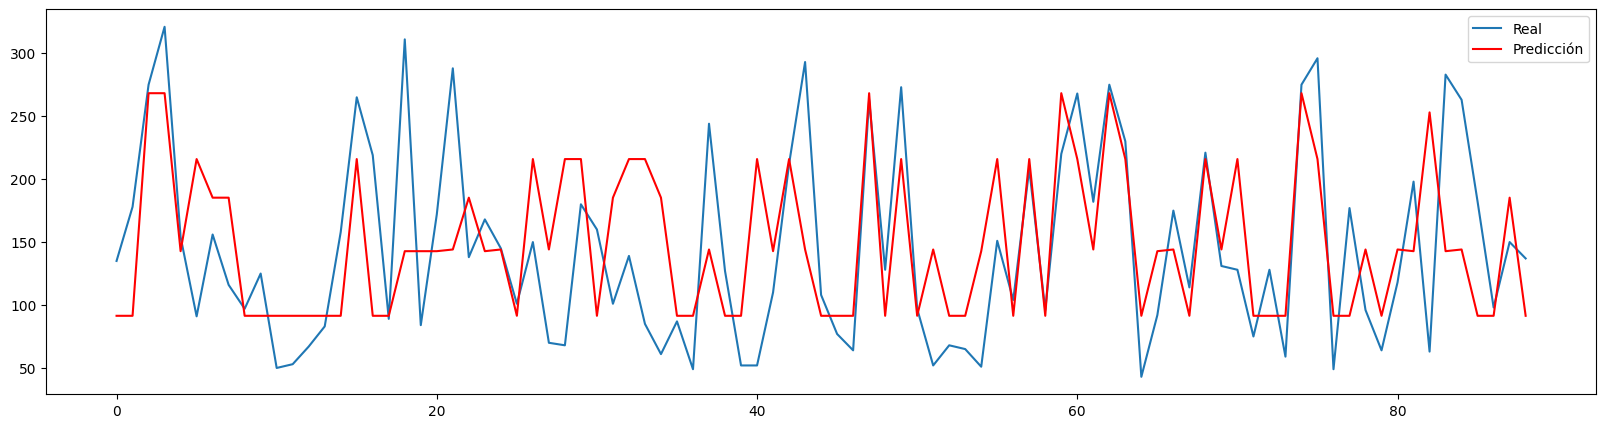

In [ ]:
# 29. Gráfica comparativa de valores reales vs predichos
Yhat = grid.predict(Xtest)

print("MSE:", mean_squared_error(Ytest, Yhat))
print("MAE:", mean_absolute_error(Ytest, Yhat))
print("R2:", r2_score(Ytest, Yhat))

plt.subplots(figsize=(20, 5))
plt.plot(Ytest, label="Real")
plt.plot(Yhat, 'r', label="Predicción")
plt.legend()
plt.show()

In [ ]:
# 30. Valores únicos predichos por el árbol
np.unique(Yhat)

array([ 91.43333333, 142.75757576, 144.10714286, 185.26086957,
       215.92063492, 253.        , 268.24      ])

In [ ]:
# 31. Lista completa de predicciones
Yhat

array([ 91.43333333,  91.43333333, 268.24      , 268.24      ,
       142.75757576, 215.92063492, 185.26086957, 185.26086957,
        91.43333333,  91.43333333,  91.43333333,  91.43333333,
        91.43333333,  91.43333333,  91.43333333, 215.92063492,
        91.43333333,  91.43333333, 142.75757576, 142.75757576,
       142.75757576, 144.10714286, 185.26086957, 142.75757576,
       144.10714286,  91.43333333, 215.92063492, 144.10714286,
       215.92063492, 215.92063492,  91.43333333, 185.26086957,
       215.92063492, 215.92063492, 185.26086957,  91.43333333,
        91.43333333, 144.10714286,  91.43333333,  91.43333333,
       215.92063492, 142.75757576, 215.92063492, 144.10714286,
        91.43333333,  91.43333333,  91.43333333, 268.24      ,
        91.43333333, 215.92063492,  91.43333333, 144.10714286,
        91.43333333,  91.43333333, 142.75757576, 215.92063492,
        91.43333333, 215.92063492,  91.43333333, 268.24      ,
       215.92063492, 144.10714286, 268.24      , 215.92

## Conclusiones

Reflexiona sobre lo realizado y explica:
1. ¿Qué indica el árbol ganador? ¿Por qué es un "ganador"?
2. ¿Qué efectos tiene el manejar los hiperparámetros?

**Reflexión:**
* Se dividió el DataFrame en subconjuntos y se construyó iterativamente el árbol, siendo calificado en cada iteración mediante validación cruzada.
* La mejor solución se obtiene en la subdivisión que tenga el rendimiento promedio más alto (p. ej., mayor score $R^2$). Es un árbol ganador porque reduce el problema del sobreajuste e intenta minimizar la brecha de error entre los valores observados y predichos al recibir datos no vistos.
* El ajuste (*tuning*) de hiperparámetros como `max_depth` limita el crecimiento desmedido del árbol, evitando la memorización (*overfitting*) y permitiendo alcanzar un equilibrio óptimo de generalización.